# Visualizing attributions

This notebook provides a way of visualizing the attributions from Tflat.

In [7]:
from path_explain import scatter_plot, summary_plot
import matplotlib.pyplot as plt
import numpy as np
from explainer_utils import get_vars, get_super_groups
import utils

config = utils.load_config('config.yaml')
display_names, group_keys = get_vars(config)

In [8]:
attr_file = 'attributions.npz' # path to npz file
_data = np.load(attr_file)
attributions = _data['attributions']
data = _data['data']
print(f"Loaded attributions from {attr_file} with shape: {attributions.shape}")

Loaded attributions from attributions.npz with shape: (5000, 394)


## Beeswarm plot

The beeswarm plot shows the top variables sorted by attributions. The color map corresponds to the feature value of each variable. 

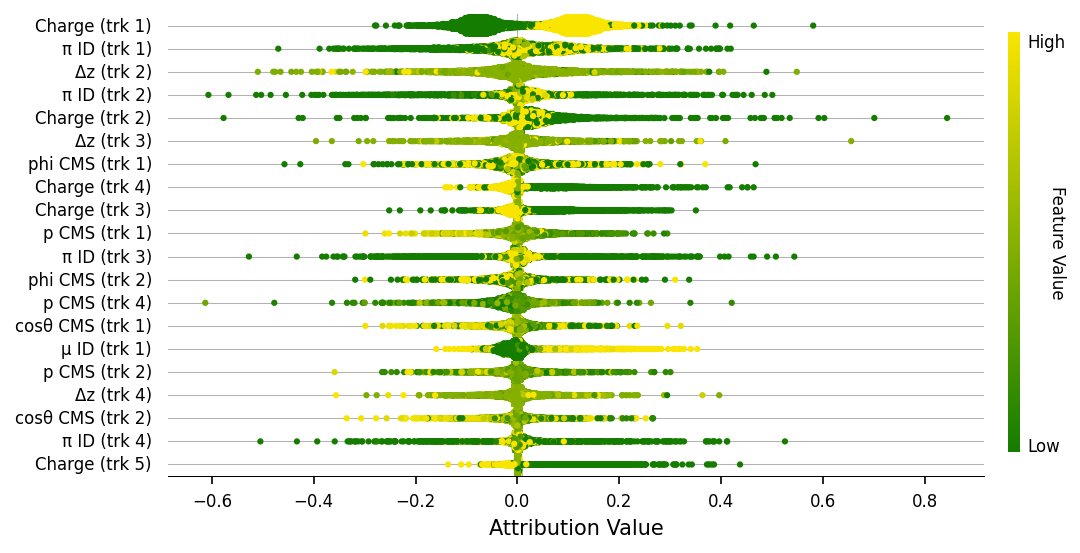

In [4]:
top_k = 20 # number of variables to display

summary_plot(attributions=attributions, 
             plot_top_k=top_k,
             feature_values=data, 
             feature_names=display_names)

## Combining tracks
Combining the tracks for each variable provides more information about the importance of each physical variable.

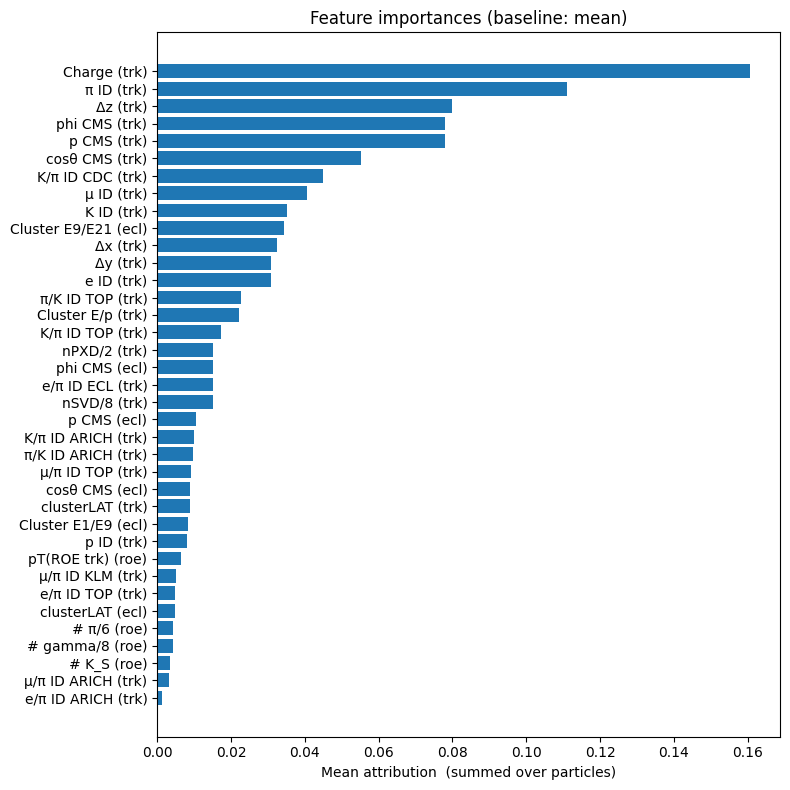

In [4]:
unique_groups = list(dict.fromkeys(group_keys))
group_index = {g: k for k, g in enumerate(unique_groups)}
col_to_group = np.array([group_index[g] for g in group_keys])

n_samples, _ = attributions.shape
n_groups = len(unique_groups)

combined_attr = np.zeros((n_samples, n_groups), dtype=attributions.dtype)

for c, g in enumerate(col_to_group):
    combined_attr[:, g] += attributions[:, c]

top_k = n_groups # n_groups plot all the variables
mean_abs = np.mean(np.abs(combined_attr), axis=0)
order = np.argsort(mean_abs)[::-1][:top_k]

plt.figure(figsize=(8, 8))
plt.barh([unique_groups[i] for i in order][::-1], mean_abs[order][::-1])
plt.xlabel('Mean attribution  (summed over particles)')
plt.title(f'Feature importances (baseline: mean)')
plt.tight_layout()
plt.show()

## Combine variables into categories
The variables are combined into one bigger category. The full variable map can be found on the file explainer_utils.py, and the official classification of the variables can be found on the Sphinx documentation: https://software.belle2.org/development/sphinx/analysis/doc/Variables.html#variables-by-group

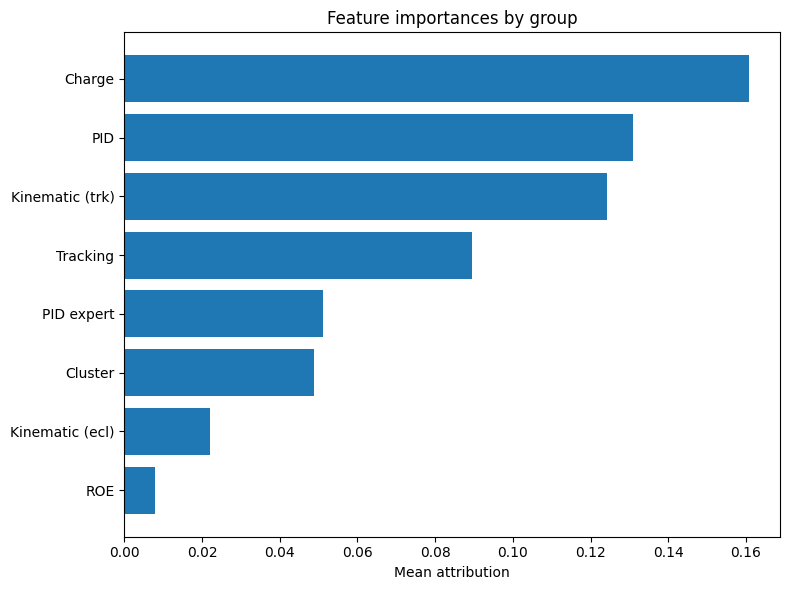

In [5]:
super_groups = get_super_groups()
label_to_super = {label: g for g, labels in super_groups.items() for label in labels}

super_names = list(super_groups)
super_idx = {g: i for i, g in enumerate(super_names)}
col_to_super = np.array([super_idx[label_to_super[g]] for g in unique_groups])

n_super = len(super_names)
combined_attr_total = np.zeros((n_samples, n_super), dtype=attributions.dtype)
for c, g in enumerate(col_to_super):
    combined_attr_total[:, g] += combined_attr[:, c]

mean_abs = np.mean(np.abs(combined_attr_total), axis=0)
order = np.argsort(mean_abs)[::-1]

plt.figure(figsize=(8, 6))
plt.barh([super_names[i] for i in order][::-1], mean_abs[order][::-1])
plt.xlabel('Mean attribution')
plt.title('Feature importances by group')
plt.tight_layout()
plt.show()

## Top 5 most important variables
The cell below show the total attribution for the top 5 variables for each track. 

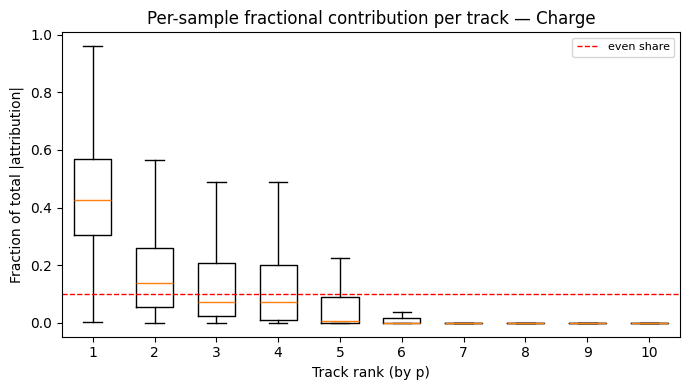

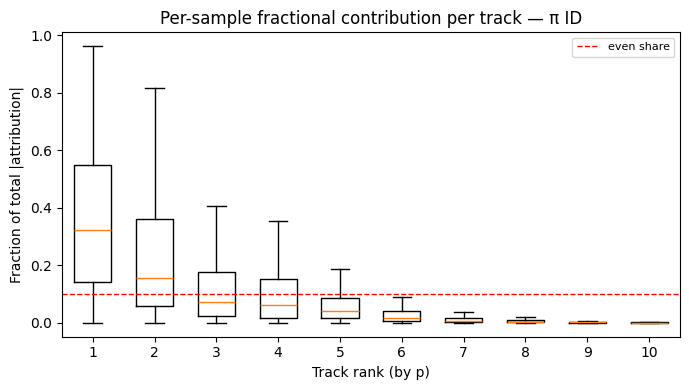

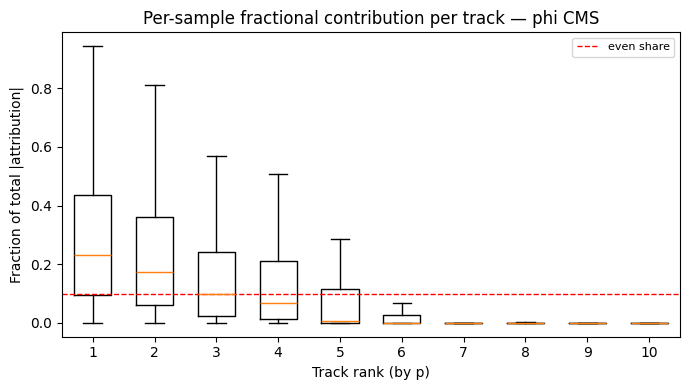

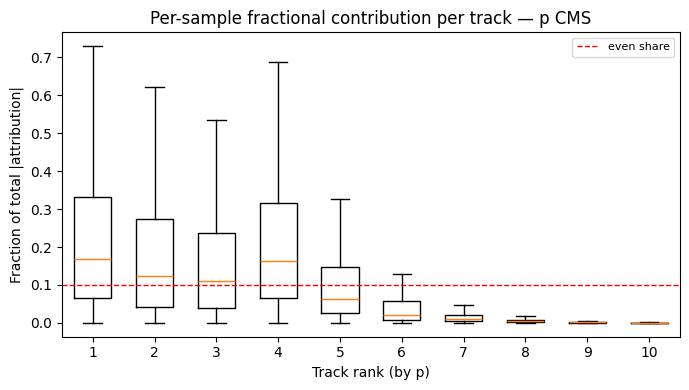

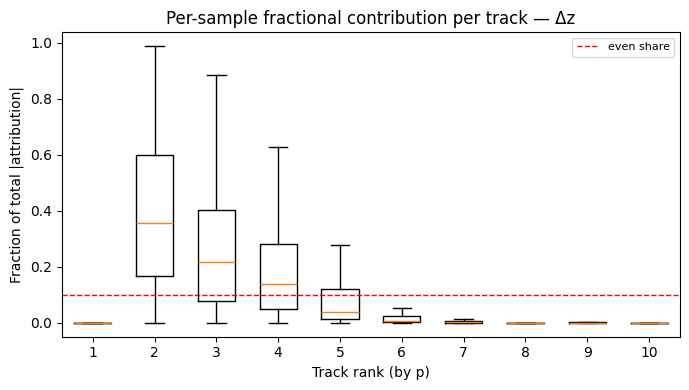

In [ ]:
parameters = config['parameters']
trk_variable_list = config['trk_variable_list']

n_trk        = parameters['num_trk']
n_trk_feats  = parameters['num_trk_features']

top5_vars = {
    'Charge':  'charge',
    'π ID':    'pionID',
    'phi CMS': 'useCMSFrame(phi)',
    'p CMS':   'useCMSFrame(p)',
    'Δz':      'dzdiff',
}

def trk_cols(var_name):
    idx = trk_variable_list.index(var_name)
    return np.array([t * n_trk_feats + idx for t in range(n_trk)])

track_ranks = np.arange(1, n_trk + 1)

even_share = 1.0 / n_trk

for label, raw in top5_vars.items():
    abs_per_track = np.abs(attributions[:, trk_cols(raw)])            
    totals        = abs_per_track.sum(axis=1, keepdims=True)   
    # Skip samples where every track contributed 0 (avoid 0/0).
    keep          = (totals.squeeze() > 0)
    frac          = abs_per_track[keep] / totals[keep]         

    plt.figure(figsize=(7, 4))
    plt.boxplot([frac[:, t] for t in range(n_trk)],
                positions=track_ranks, widths=0.6, showfliers=False)
    plt.axhline(even_share, color='red', linestyle='--', linewidth=1,
                label=f'even share')
    plt.xlabel('Track rank (by p)')
    plt.ylabel('Fraction of total attribution')
    plt.title(f'Per-sample fractional contribution per track — {label}')
    plt.xticks(track_ranks, track_ranks)
    plt.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

## Particle ID for tracks

The box plot for the momentum shows that the track 4 has a different behavior, having greater importance than the previous track. Plotting the particle ID could provide a little more information abou the origin of this artifact.

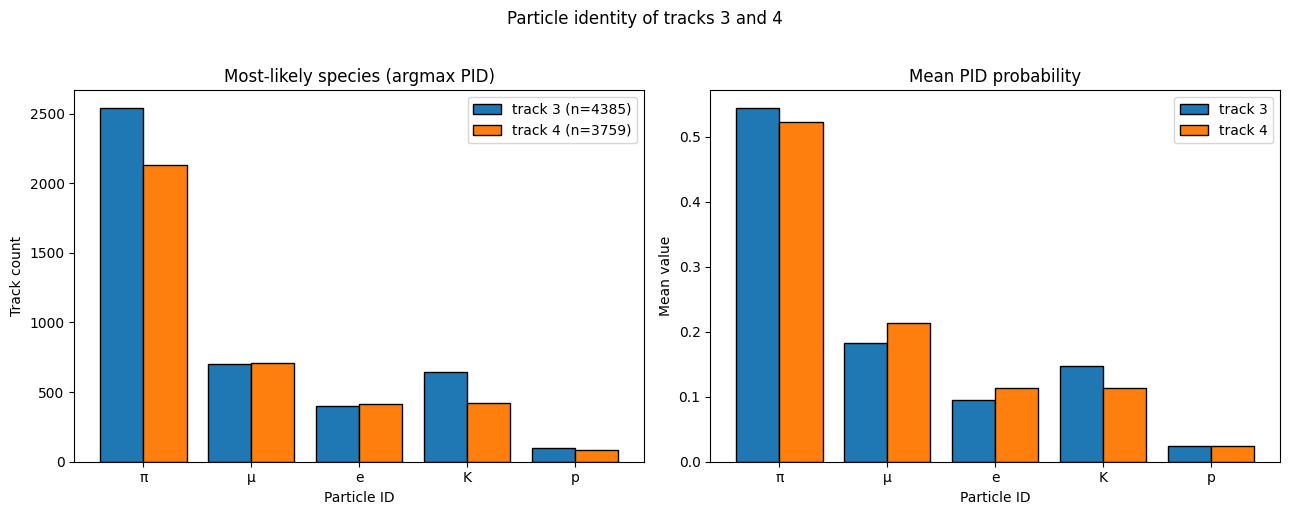

In [28]:
def trk_col(var_name, t):
    """Column index in attributions/test_x for 0-based track index t and variable name."""
    return t * n_trk_feats + trk_variable_list.index(var_name)

ranks = [3, 4] # Select the ranks to show

pid_vars  = ['pionID', 'muonID', 'electronID', 'kaonID', 'protonID']
pid_names = ['π', 'μ', 'e', 'K', 'p']

x = np.arange(len(pid_names))
w = 0.4
offsets = [-w / 2, w / 2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for off, rank in zip(offsets, ranks):
    t = rank - 1
    cols = [trk_col(v, t) for v in pid_vars]
    pid_matrix = data[:, cols]                   

    # A track is "present" if its PID row isn't all-zero (zero = padded/absent slot).
    present = pid_matrix.any(axis=1)
    pid_present = pid_matrix[present]

    assigned = np.argmax(pid_present, axis=1)
    counts   = np.bincount(assigned, minlength=len(pid_vars))
    axes[0].bar(x + off, counts, width=w, edgecolor='black',
                label=f'track {rank} (n={present.sum()})')

    mean_pid = pid_present.mean(axis=0)
    axes[1].bar(x + off, mean_pid, width=w, edgecolor='black', label=f'track {rank}')

axes[0].set_title('Most-likely species (argmax PID)')
axes[0].set_ylabel('Track count')
axes[1].set_title('Mean PID probability')
axes[1].set_ylabel('Mean value')
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(pid_names)
    ax.set_xlabel('Particle ID')
    ax.legend()
fig.suptitle(f'Particle identity of tracks {ranks[0]} and {ranks[1]}', y=1.02)
plt.tight_layout()
plt.show()